In [1]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pylab as plt
import duckdb
from sklearn.model_selection import train_test_split 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


sales_csv=r"C:/M5 Data/m5-forecasting-accuracy/sales_train_evaluation.csv"
calendar_csv=r"C:/M5 Data/m5-forecasting-accuracy/calendar.csv"
price_csv= r"C:/M5 Data/m5-forecasting-accuracy/sell_prices.csv"

sales_df=pd.read_csv(f"{sales_csv}")
print(sales_df['item_id'].unique())
sales_df=sales_df[sales_df['item_id']=='FOODS_3_825']

['HOBBIES_1_001' 'HOBBIES_1_002' 'HOBBIES_1_003' ... 'FOODS_3_825'
 'FOODS_3_826' 'FOODS_3_827']


In [2]:



cols = sales_df.columns

day_cols = [c for c in cols if c.startswith("d_")]
print(f"Found {len(day_cols)} daily columns: {day_cols[:5]} ... {day_cols[-5:]}")


full_query = f"""
   WITH UNPIVOT_SALES AS(
   SELECT 
       id, item_id, dept_id, cat_id, store_id, state_id,
       Day, value AS Sales_Quantity
   FROM sales_df
   UNPIVOT(value FOR Day IN ({', '.join(day_cols)}))
   )


   SELECT s.*,c.*,p.sell_price
   FROM UNPIVOT_SALES AS s
   LEFT JOIN read_csv_auto('{calendar_csv}') AS c
   ON s.Day=c.d
   LEFT JOIN read_csv_auto('{price_csv}') AS p
   ON s.store_id = p.store_id
      AND s.item_id = p.item_id
      AND c.wm_yr_wk = p.wm_yr_wk

"""
full_data=duckdb.query(full_query).df()

#peep at data
print(full_data.head())

#Rows with Missing values
missing_rows = full_data.isna().any(axis=1).sum()
print("Number of rows with missing values:", missing_rows)

#Missing values in each column
for column in full_data.columns:
    print(f"missing values in {column} : {full_data[column].isna().sum()}")

#replacing null events with No event
full_data['event_name_1']=full_data['event_name_1'].fillna("No_event")
full_data['event_type_1']=full_data['event_type_1'].fillna("No_event")
full_data['event_name_2']=full_data['event_name_2'].fillna("No_event")
full_data['event_type_2']=full_data['event_type_2'].fillna("No_event")


full_data = full_data.sort_values(by='date')
full_data['date']=pd.to_datetime(full_data['date']).dt.normalize()


#Days with missing prices
mask=full_data['sell_price'].isna()==True 

print("There are missing prices on these days")
print(full_data.loc[mask,['date']].reset_index(drop=True))




Found 1941 daily columns: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5'] ... ['d_1937', 'd_1938', 'd_1939', 'd_1940', 'd_1941']
                            id      item_id  dept_id cat_id store_id state_id  \
0  FOODS_3_825_CA_4_evaluation  FOODS_3_825  FOODS_3  FOODS     CA_4       CA   
1  FOODS_3_825_CA_4_evaluation  FOODS_3_825  FOODS_3  FOODS     CA_4       CA   
2  FOODS_3_825_CA_4_evaluation  FOODS_3_825  FOODS_3  FOODS     CA_4       CA   
3  FOODS_3_825_CA_4_evaluation  FOODS_3_825  FOODS_3  FOODS     CA_4       CA   
4  FOODS_3_825_CA_4_evaluation  FOODS_3_825  FOODS_3  FOODS     CA_4       CA   

    Day  Sales_Quantity       date  wm_yr_wk  ...  year     d  event_name_1  \
0   d_7               2 2011-02-04     11101  ...  2011   d_7          None   
1  d_14               0 2011-02-11     11102  ...  2011  d_14          None   
2  d_21               0 2011-02-18     11103  ...  2011  d_21          None   
3  d_28               1 2011-02-25     11104  ...  2011  d_28          None   
4

Text(0.5, 0, 'Day')

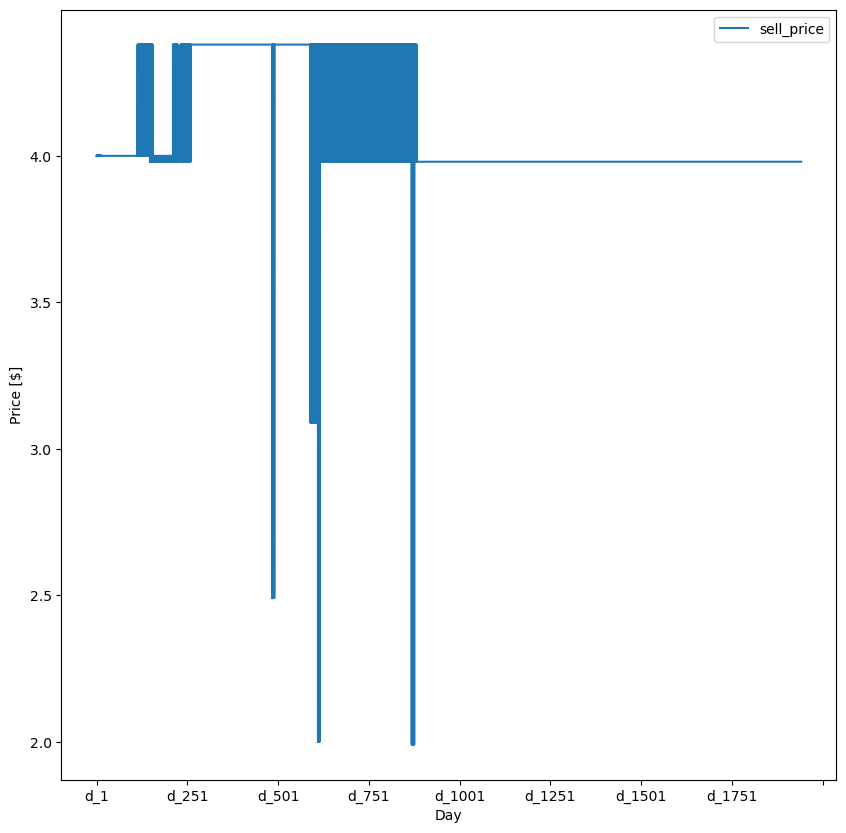

In [3]:
# plotting price overtime with no interpolation
ax=full_data[['Day', 'sell_price']].plot(x='Day', y='sell_price', figsize=(10,10))
ax.set_ylabel("Price [$]")
ax.set_xlabel("Day")


(19410, 23)
(19410, 3)


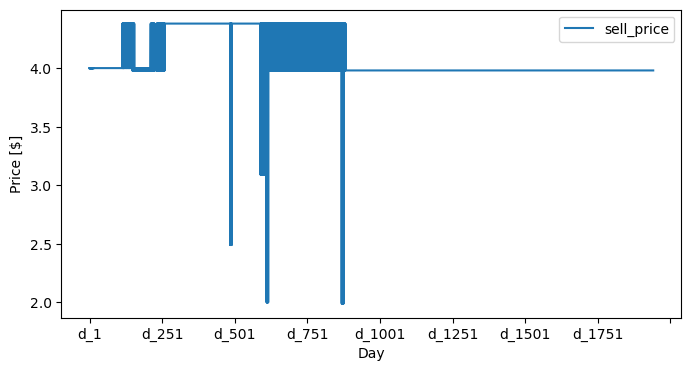

In [4]:
#interpolation test

df=full_data[['Day','sell_price','Sales_Quantity']].copy()
df['sell_price'] = df['sell_price'].interpolate(method='polynomial',order=5)

other=df[['Day', 'sell_price']].plot(x='Day', y='sell_price', figsize=(8,4))
other.set_ylabel("Price [$]")
other.set_xlabel("Day")

print(full_data.shape)
print(df.shape)






In [5]:
# interpolating prices   no need to interpolate
#full_data['sell_price'] = (full_data['sell_price'].interpolate(method='polynomial',order=2).interpolate(method='linear', limit_direction='both'))
#print(full_data['sell_price'].isna().sum())

In [6]:
#Stats
print("---------sales quantity------")
print(full_data['Sales_Quantity'].describe())
print("---------sales price------")
print(full_data['sell_price'].describe())
print("")
print("Number of missing sales quantities:", full_data['Sales_Quantity'].isna().sum())
print("Number of missing prices:", full_data['sell_price'].isna().sum())

print("Number of zero sales:", (full_data['Sales_Quantity']==0).sum())
print("Number of non-zero sales:", (full_data['Sales_Quantity']>0).sum())


print("")
print("")
print("Every valuecount below is a percentage")
print("")
print("")
print(full_data['item_id'].value_counts(normalize=True)*100)
print("")
print("")
print(full_data['dept_id'].value_counts(normalize=True)*100)
print("")
print("")
print(full_data['cat_id'].value_counts(normalize=True)*100)
print("")
print("")
print(full_data['store_id'].value_counts(normalize=True)*100)
print("")
print("")
print(full_data['state_id'].value_counts(normalize=True)*100)
print("")
print("")
print(full_data['event_name_1'].value_counts(normalize=True)*100)
print("")
print("")
print(full_data['event_type_1'].value_counts(normalize=True)*100)
print("")
print("")
print(full_data['event_name_2'].value_counts(normalize=True)*100)
print("")
print("")
print(full_data['event_type_2'].value_counts(normalize=True)*100)
print("")
print("")
print(full_data['snap_CA'].value_counts(normalize=True)*100)
print("")
print("")
print(full_data['snap_TX'].value_counts(normalize=True)*100)
print("")
print("")
print(full_data['snap_WI'].value_counts(normalize=True)*100)




---------sales quantity------
count    19410.000000
mean         0.714426
std          1.206190
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         20.000000
Name: Sales_Quantity, dtype: float64
---------sales price------
count    19389.000000
mean         4.110061
std          0.200744
min          1.990000
25%          3.980000
50%          3.980000
75%          4.380000
max          4.380000
Name: sell_price, dtype: float64

Number of missing sales quantities: 0
Number of missing prices: 21
Number of zero sales: 11909
Number of non-zero sales: 7501


Every valuecount below is a percentage


item_id
FOODS_3_825    100.0
Name: proportion, dtype: float64


dept_id
FOODS_3    100.0
Name: proportion, dtype: float64


cat_id
FOODS    100.0
Name: proportion, dtype: float64


store_id
WI_3    10.0
TX_2    10.0
TX_1    10.0
CA_3    10.0
CA_4    10.0
TX_3    10.0
WI_2    10.0
WI_1    10.0
CA_1    10.0
CA_2    10.0
Name: proportion, dtype: float6

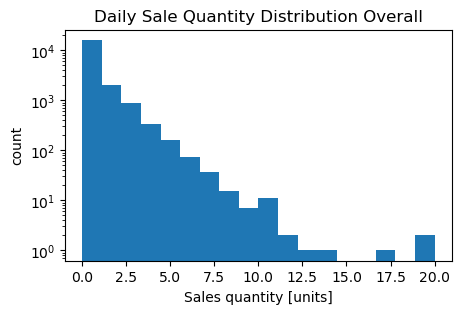

In [62]:

plt.figure(figsize=(5,3))

full_data['Sales_Quantity'].plot.hist(bins = full_data['Sales_Quantity'].nunique())   # bins = int(np.sqrt(df.shape[0])) 
                        # bins = df['age'].nunique()
#plt.semilogx()
plt.semilogy()
plt.xlabel('Sales quantity [units]')
plt.ylabel('count')
plt.title("Daily Sale Quantity Distribution Overall")
plt.show()

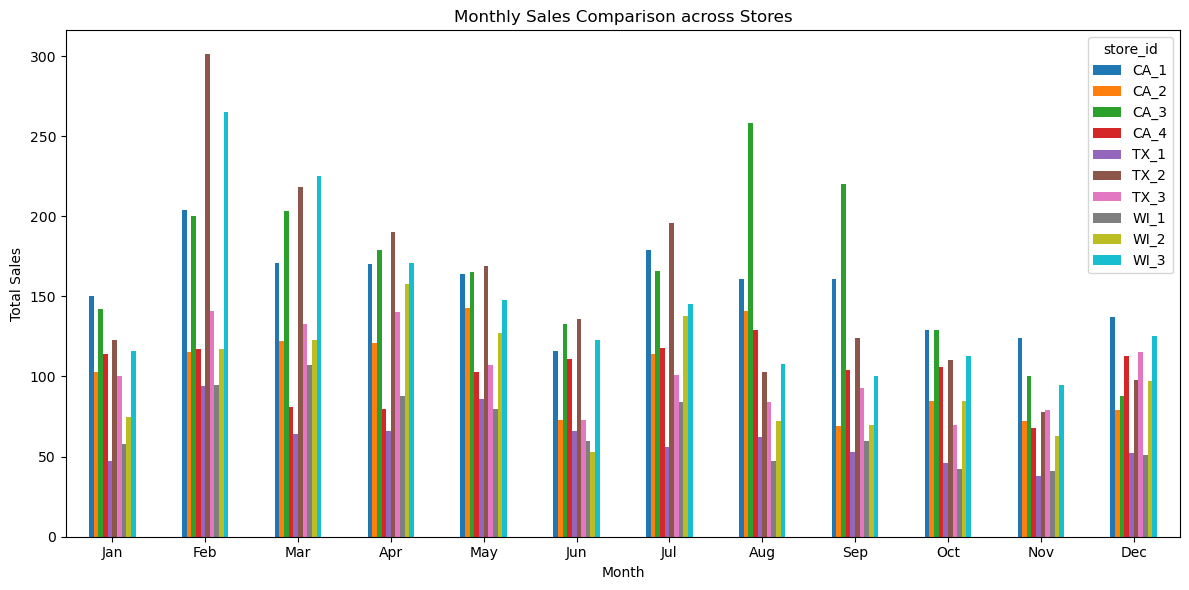

In [63]:
monthly_sales_by_store=(
    full_data.groupby(['month','store_id'])['Sales_Quantity'].sum().unstack()
)

monthly_sales_by_store.plot(kind='bar',figsize=(12,6))
plt.title('Monthly Sales Comparison across Stores')
plt.xlabel('Month')

plt.xticks(ticks=range(len(full_data['month'].unique())),labels=['Jan','Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],rotation=360)
plt.ylabel('Total Sales')
plt.tight_layout()
plt.legend(title='store_id')
plt.show()

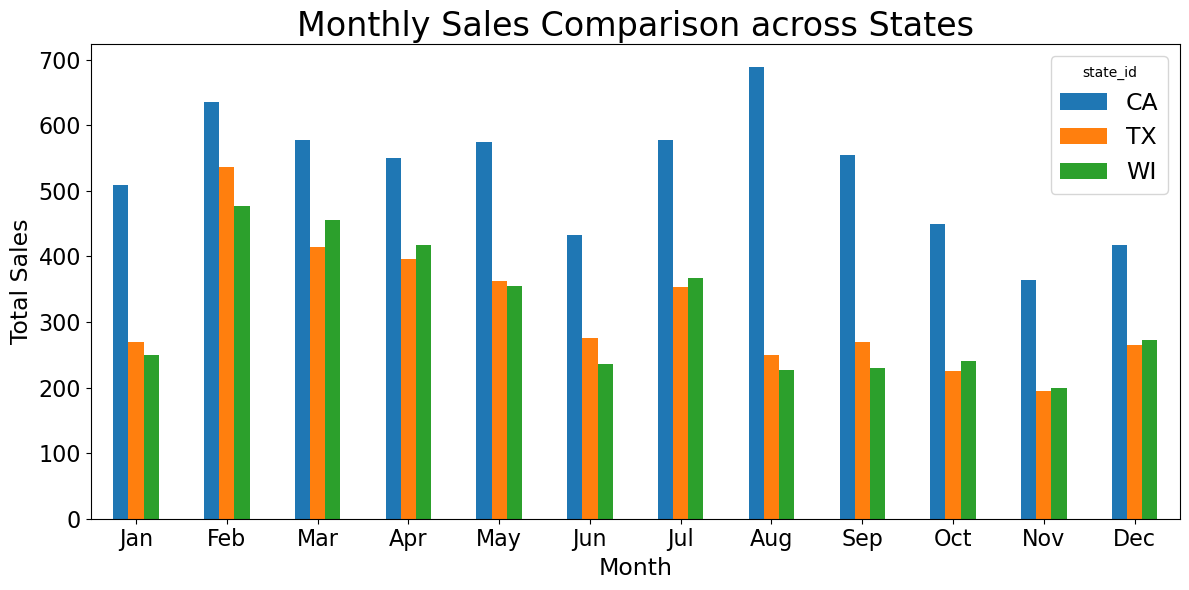

In [64]:
monthly_sales_by_store=(
    full_data.groupby(['month','state_id'])['Sales_Quantity'].sum().unstack()
)

monthly_sales_by_store.plot(kind='bar',figsize=(12,6))
plt.title('Monthly Sales Comparison across States',fontsize=24)
plt.xlabel('Month',fontsize=17)
plt.xticks(rotation=360, fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('Total Sales',fontsize=17)
plt.tight_layout()
plt.xticks(ticks=range(len(full_data['month'].unique())),labels=['Jan','Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],rotation=360)
plt.legend(title='state_id',fontsize=17)
plt.show()

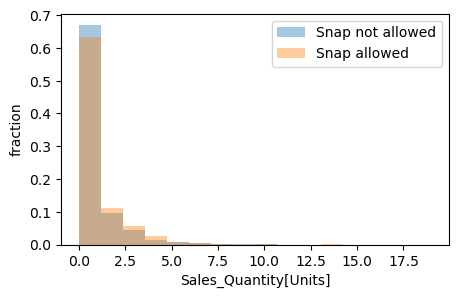

In [65]:
categories = full_data['snap_CA'].unique()
CA_data=full_data[full_data['state_id']=='CA']
bin_range = (CA_data['Sales_Quantity'].min(),CA_data['Sales_Quantity'].max())

plt.figure(figsize=(5,3))

for c in categories:
    plt.hist(CA_data[CA_data['snap_CA']==c]['Sales_Quantity'],alpha=0.4,label=c,range=bin_range,bins = CA_data['Sales_Quantity'].nunique(),density=True)
plt.legend(labels=['Snap not allowed', 'Snap allowed'])
plt.ylabel('fraction')
plt.xlabel('Sales_Quantity[Units]')
plt.show()

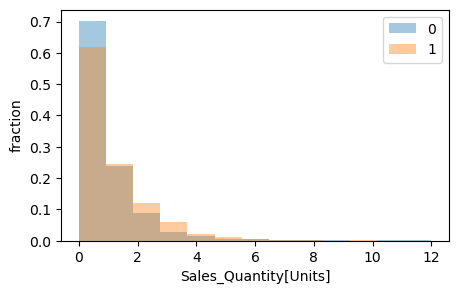

In [66]:
categories = full_data['snap_TX'].unique()
TX_data=full_data[full_data['state_id']=='TX']
bin_range = (TX_data['Sales_Quantity'].min(),TX_data['Sales_Quantity'].max())

plt.figure(figsize=(5,3))

for c in categories:
    plt.hist(TX_data[TX_data['snap_TX']==c]['Sales_Quantity'],alpha=0.4,label=c,range=bin_range,bins = TX_data['Sales_Quantity'].nunique(),density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('Sales_Quantity[Units]')
plt.show()

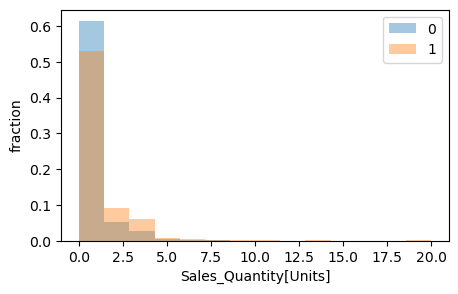

In [67]:
categories = full_data['snap_WI'].unique()
WI_data=full_data[full_data['state_id']=='WI']
bin_range = (WI_data['Sales_Quantity'].min(),WI_data['Sales_Quantity'].max())

plt.figure(figsize=(5,3))

for c in categories:
    plt.hist(WI_data[WI_data['snap_WI']==c]['Sales_Quantity'],alpha=0.4,label=c,range=bin_range,bins = WI_data['Sales_Quantity'].nunique(),density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('Sales_Quantity[Units]')
plt.show()

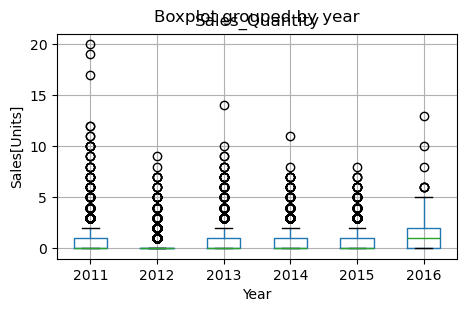

In [68]:

full_data[['Sales_Quantity','year']].boxplot(by='year',figsize=(5,3))
plt.ylabel('Sales[Units]')
plt.xlabel('Year')
plt.show()

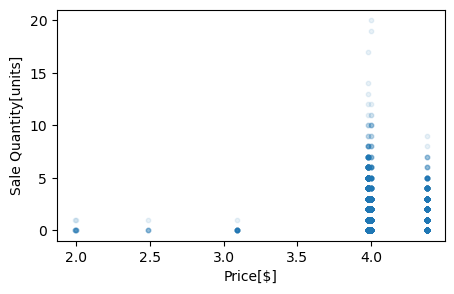

In [69]:

df.plot.scatter('sell_price','Sales_Quantity',figsize=(5,3),alpha=0.1,s=10) # alpha=0.1,s=10
plt.xlabel('Price[$]')
plt.ylabel('Sale Quantity[units]')
plt.show()


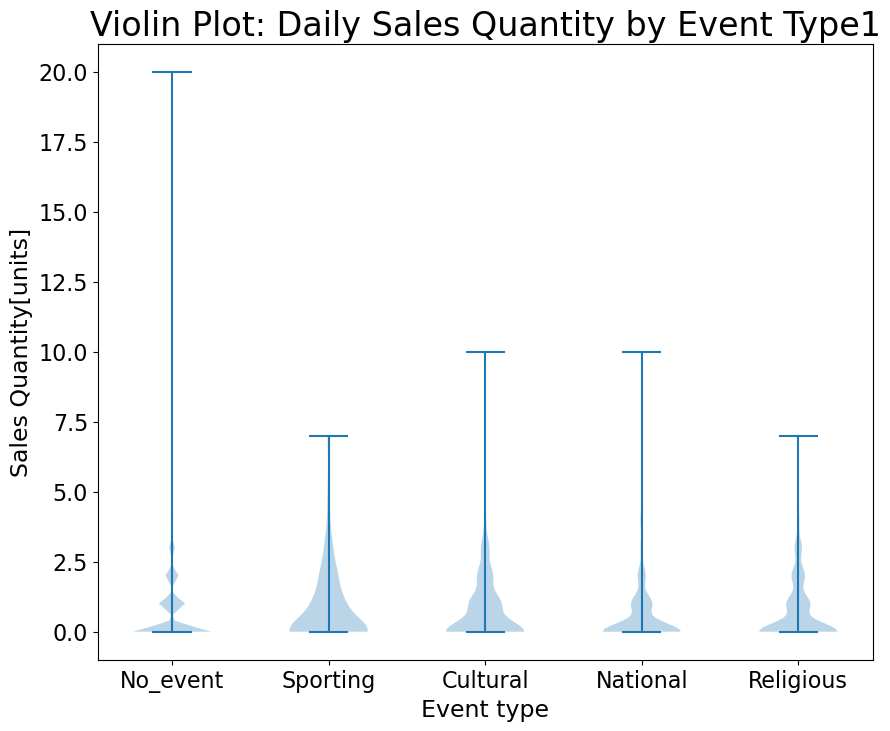

In [70]:

dataset=[]
for e_type in full_data['event_type_1'].unique():
    dataset.append(full_data[full_data['event_type_1']==e_type]['Sales_Quantity'].values)


plt.figure(figsize=(10,8))

plt.violinplot(dataset = dataset)
plt.xticks(range(1,len(dataset)+1),full_data['event_type_1'].unique())
plt.ylabel('Sales Quantity[units]',fontsize=17)
plt.xlabel('Event type',fontsize=17)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('Violin Plot: Daily Sales Quantity by Event Type1',fontsize=24)
plt.show()

In [71]:
#########plot the autocorelation curve in lecture notes

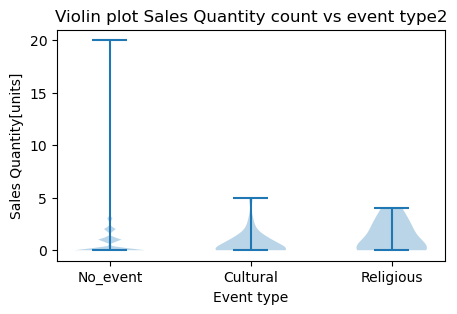

In [72]:
dataset=[]
for e_type in full_data['event_type_2'].unique():
    dataset.append(full_data[full_data['event_type_2']==e_type]['Sales_Quantity'].values)


plt.figure(figsize=(5,3))

plt.violinplot(dataset = dataset)
plt.xticks(range(1,len(dataset)+1),full_data['event_type_2'].unique())
plt.ylabel('Sales Quantity[units]')
plt.xlabel('Event type')
plt.title('Violin plot Sales Quantity count vs event type2')
plt.show()

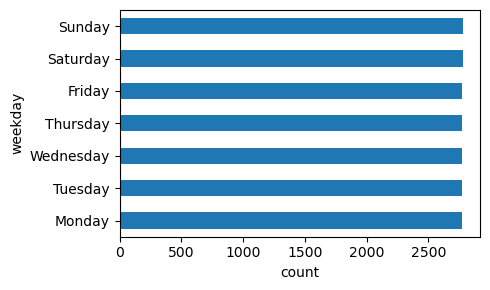

In [73]:
plt.figure(figsize=(5,3))
correct_order=['Monday','Tuesday','Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
full_data['weekday'].value_counts().reindex(correct_order).plot.barh()
plt.xlabel('count')
plt.ylabel('weekday')
#plt.title('correct!')
plt.tight_layout()
plt.show()

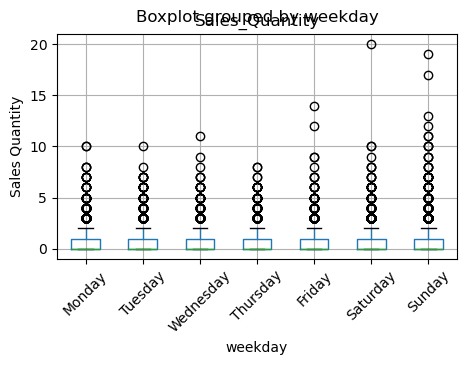

In [74]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Create a temporary categorical series for plotting
weekday_cat = pd.Categorical(full_data['weekday'], categories=weekday_order, ordered=True)

full_data[['Sales_Quantity','weekday']].assign(weekday=weekday_cat).boxplot(by='weekday',figsize=(5,3))
plt.ylabel('Sales Quantity')
plt.xlabel('weekday')
plt.xticks(rotation=45)
plt.show()

In [75]:
#stores in which product was sold
print(full_data['store_id'].unique())

['TX_2' 'WI_2' 'TX_1' 'TX_3' 'WI_3' 'CA_2' 'WI_1' 'CA_3' 'CA_4' 'CA_1']


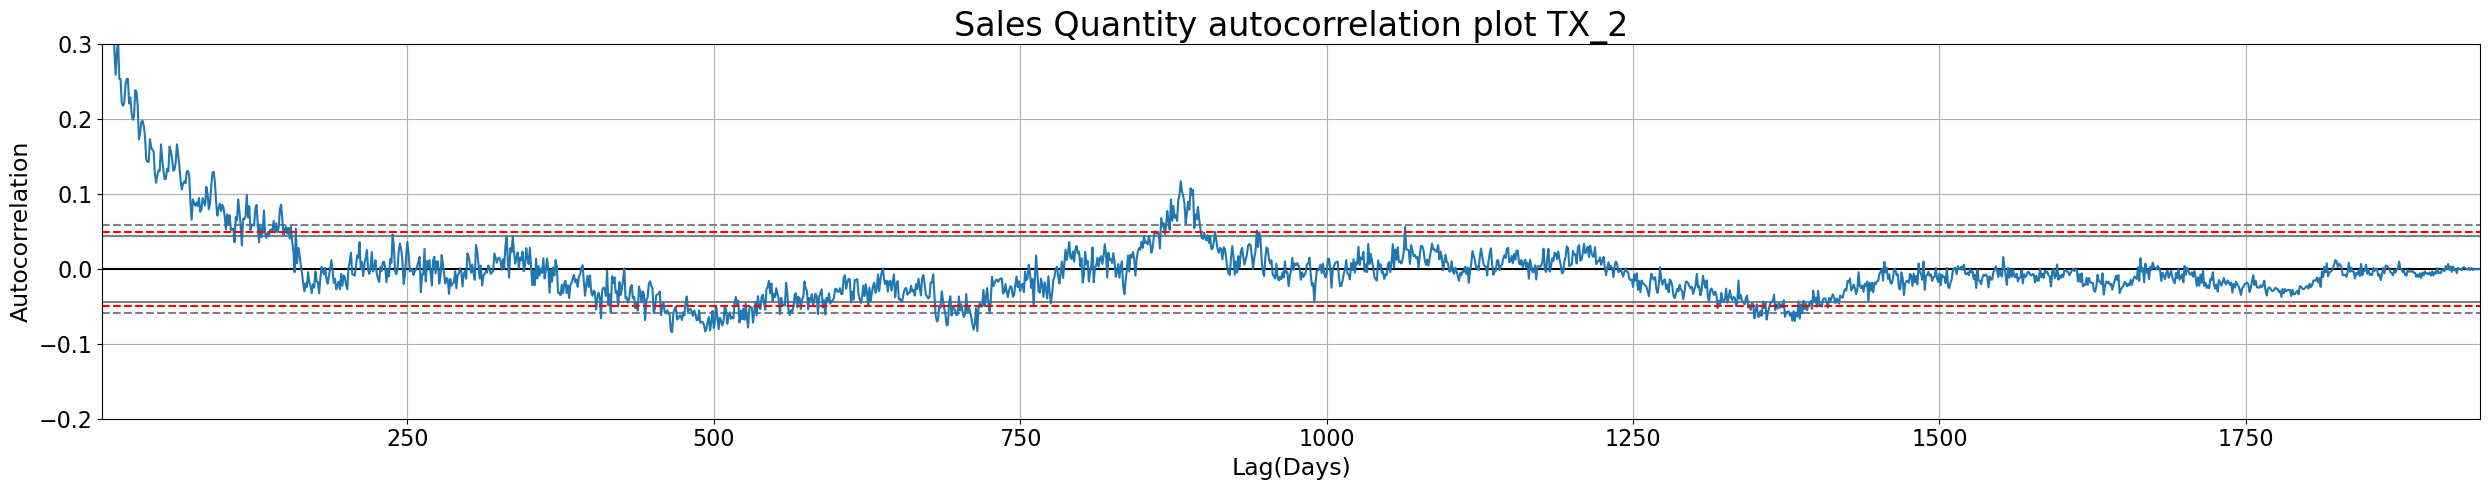

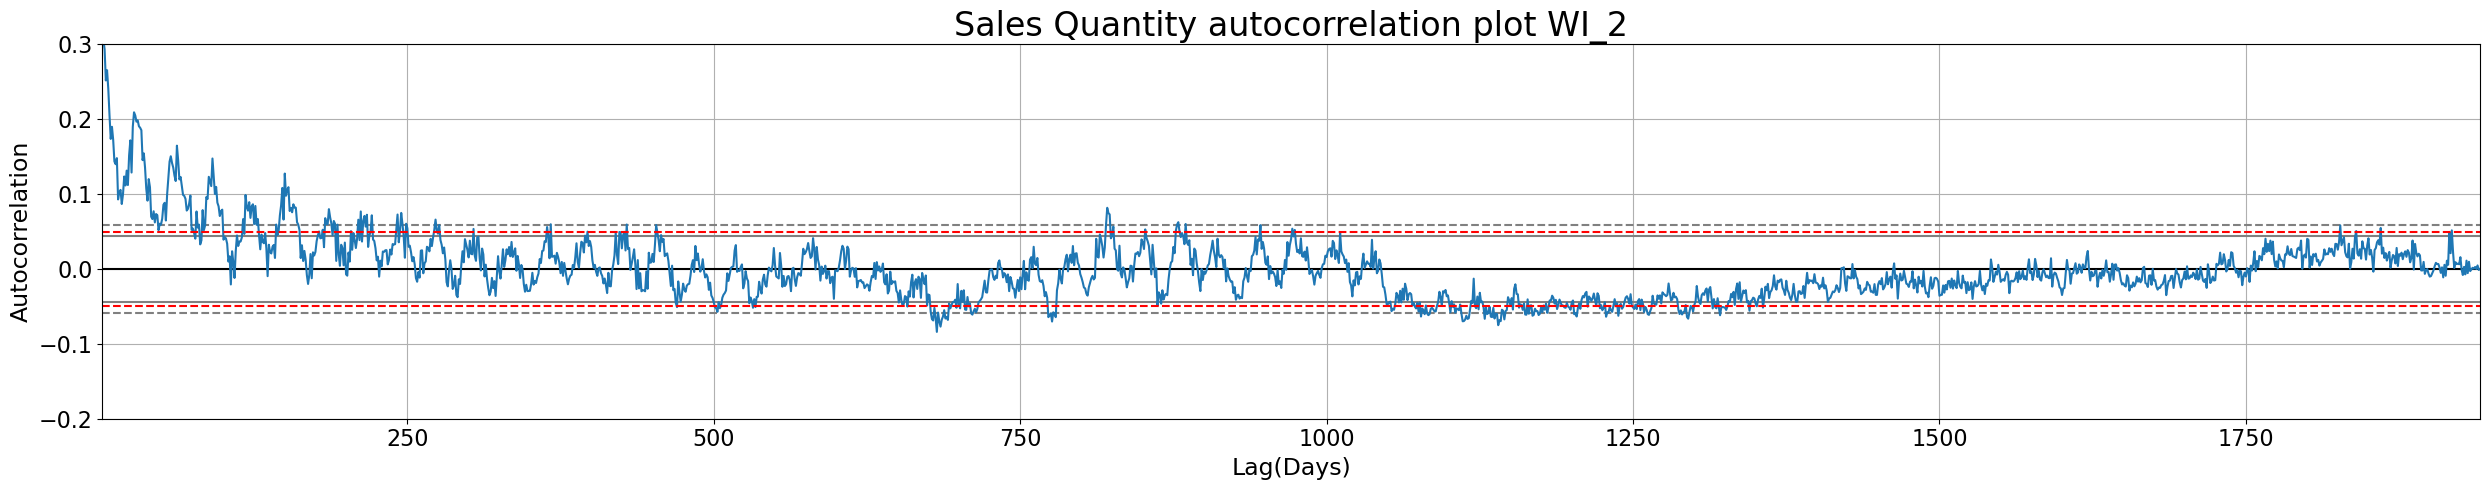

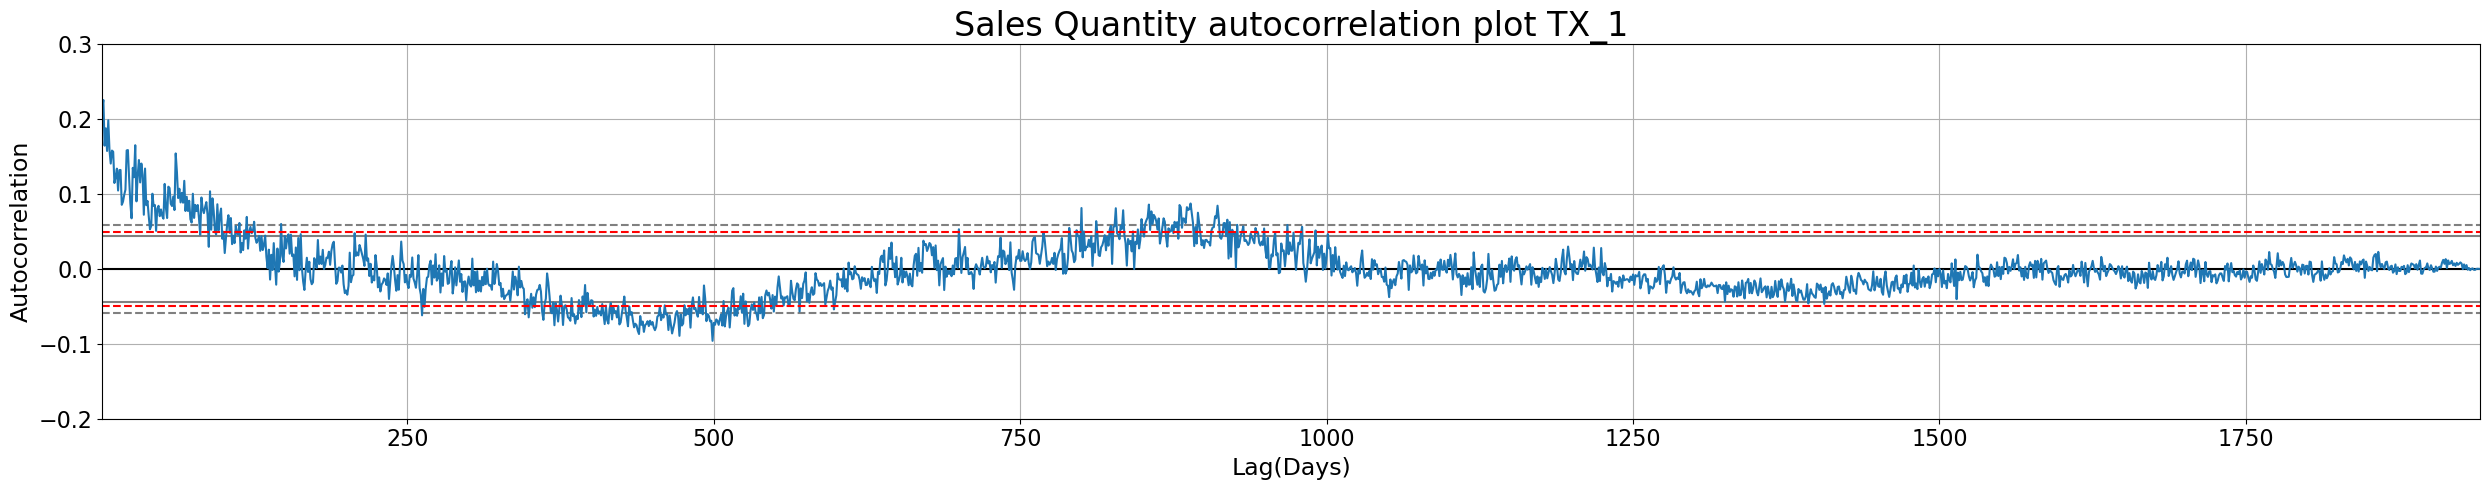

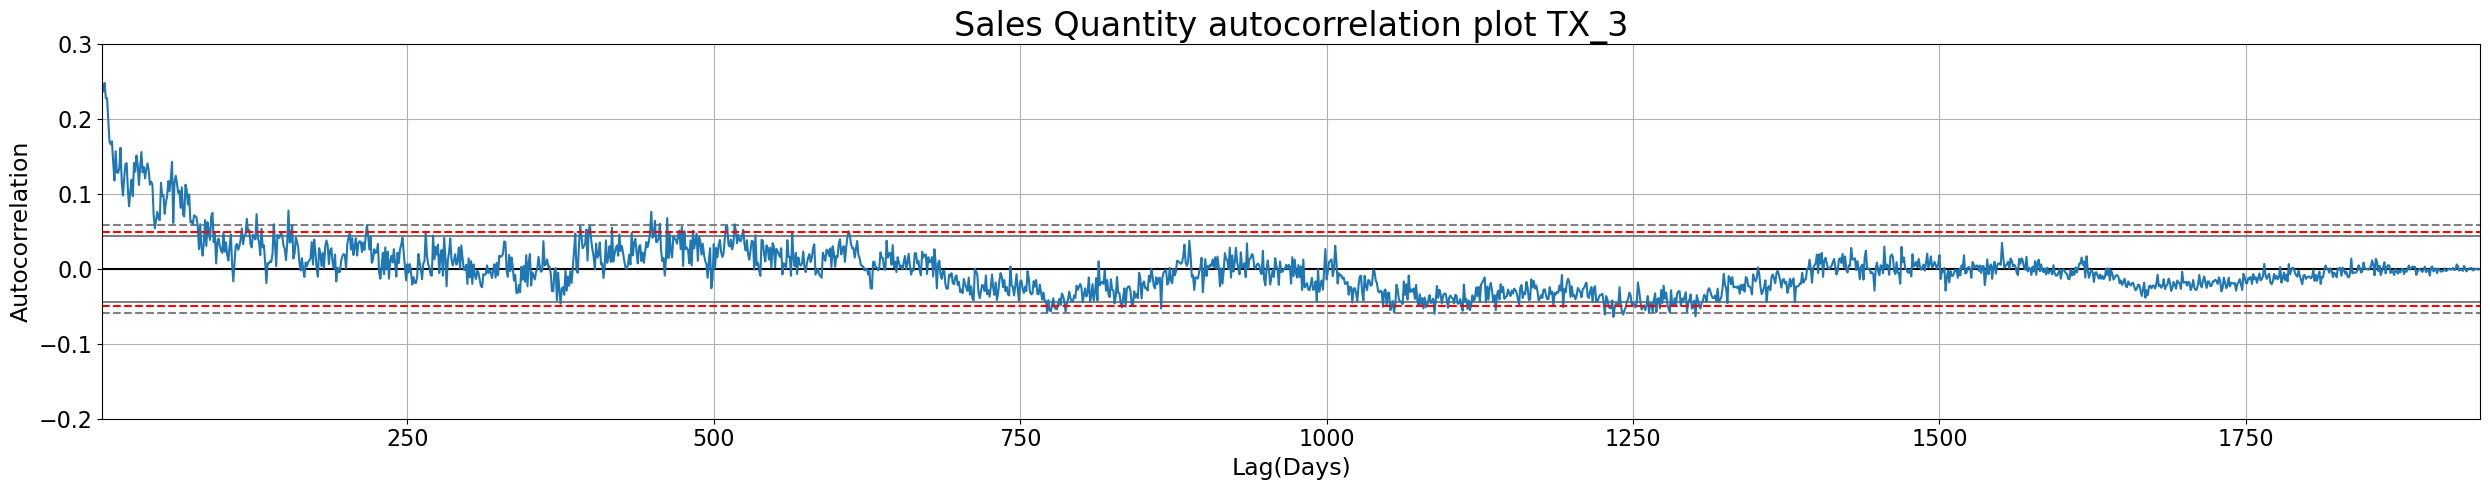

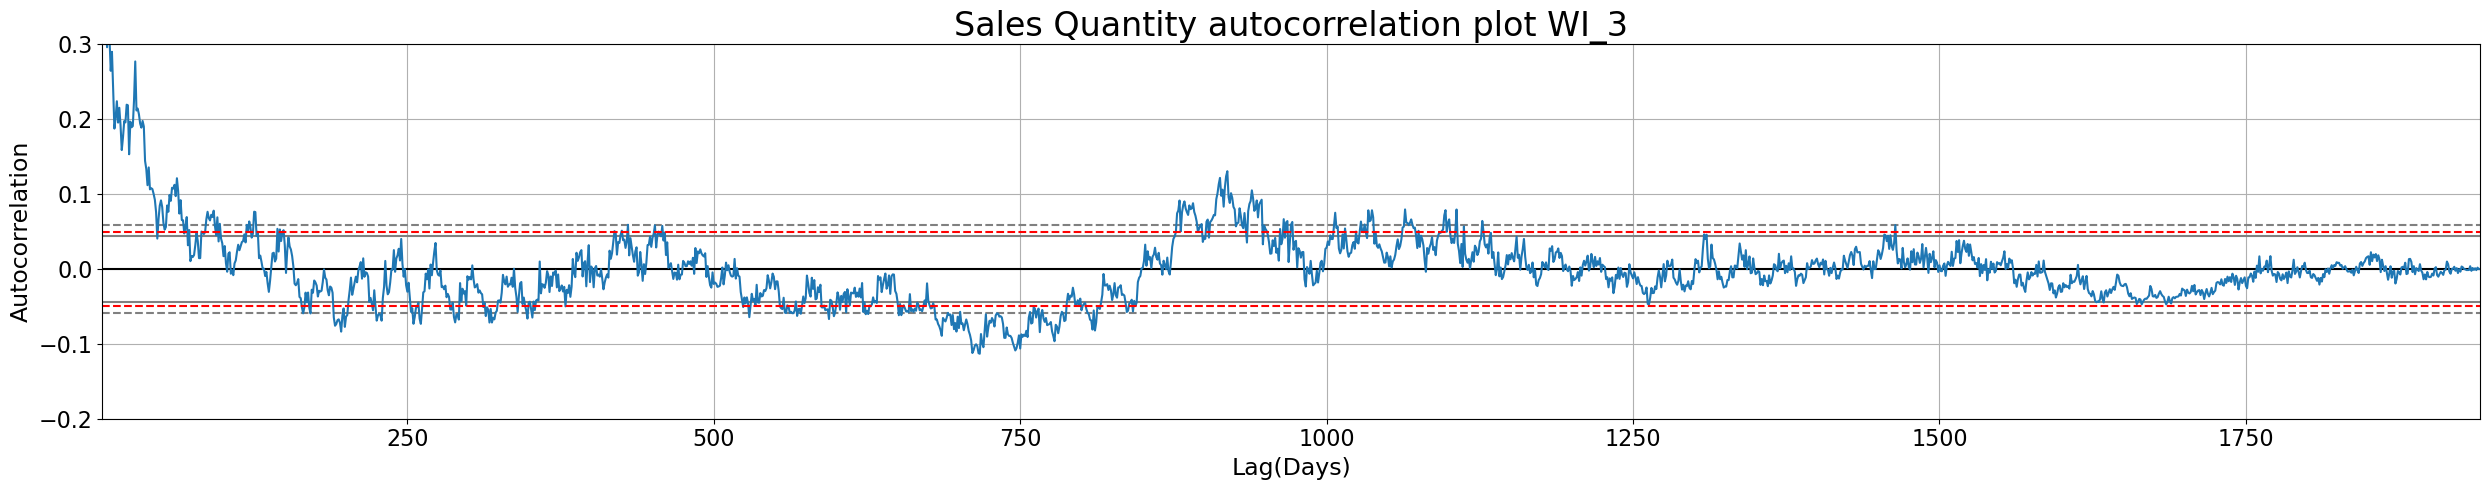

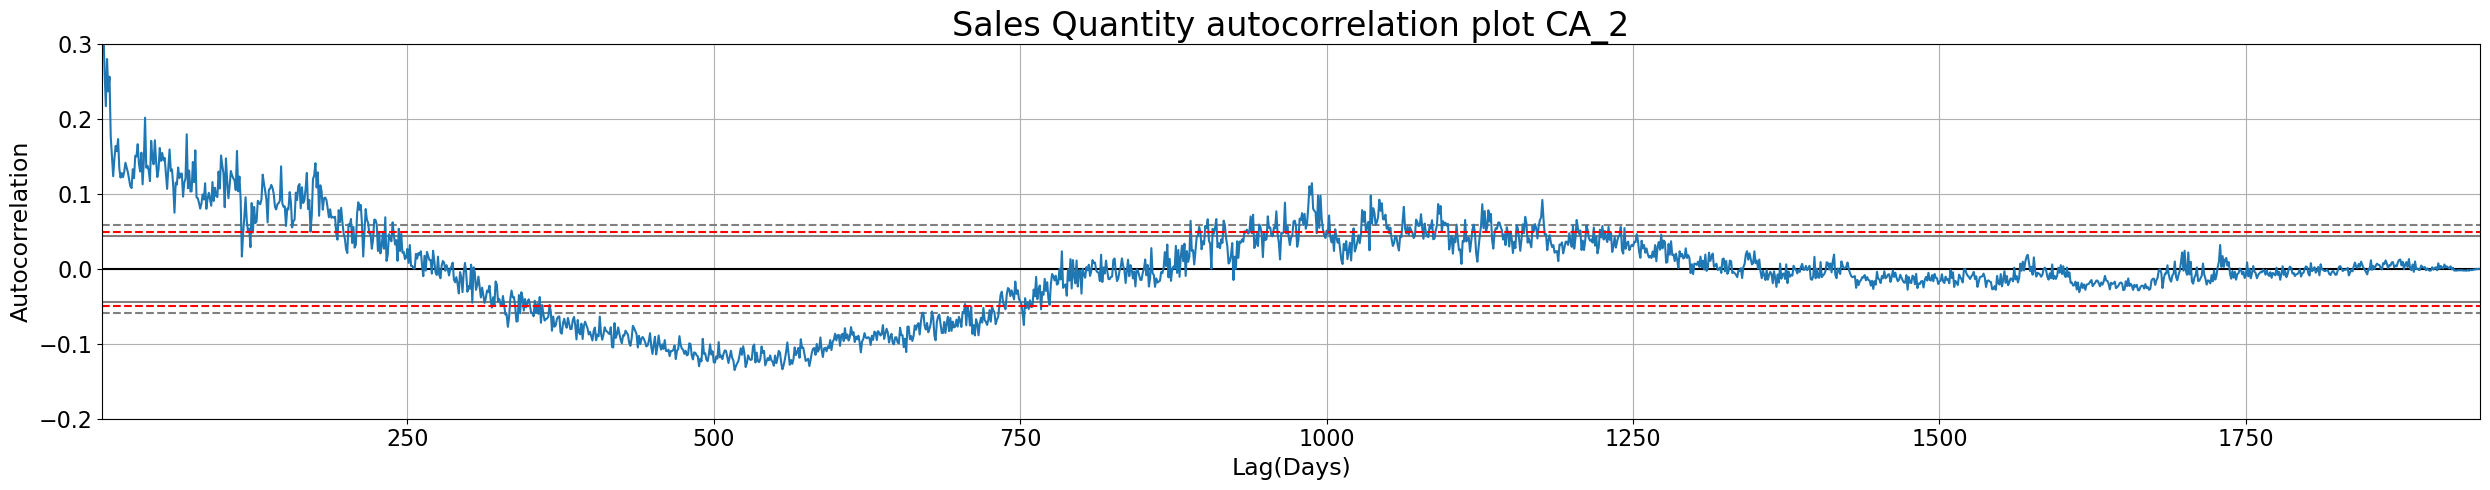

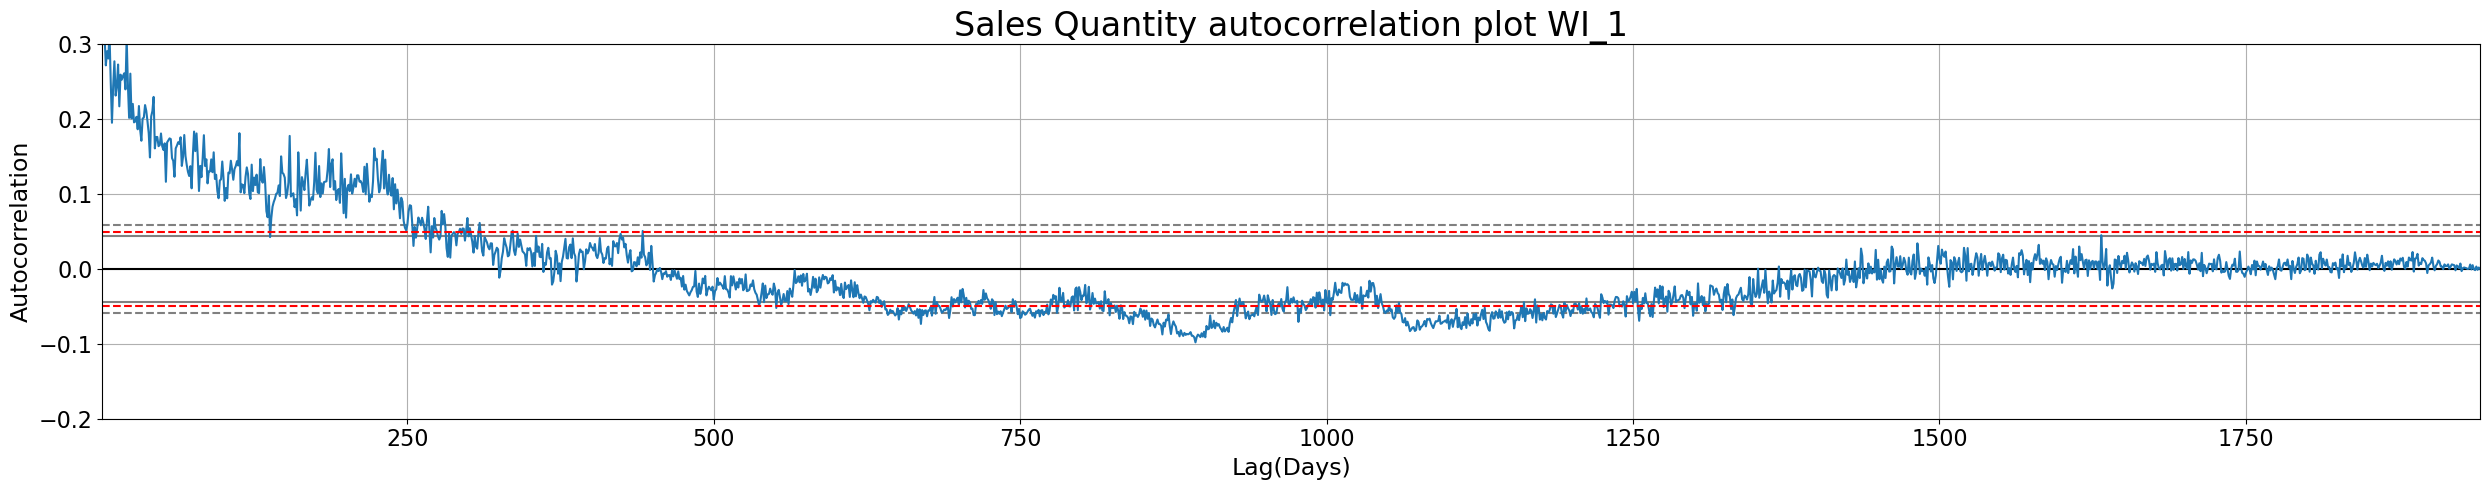

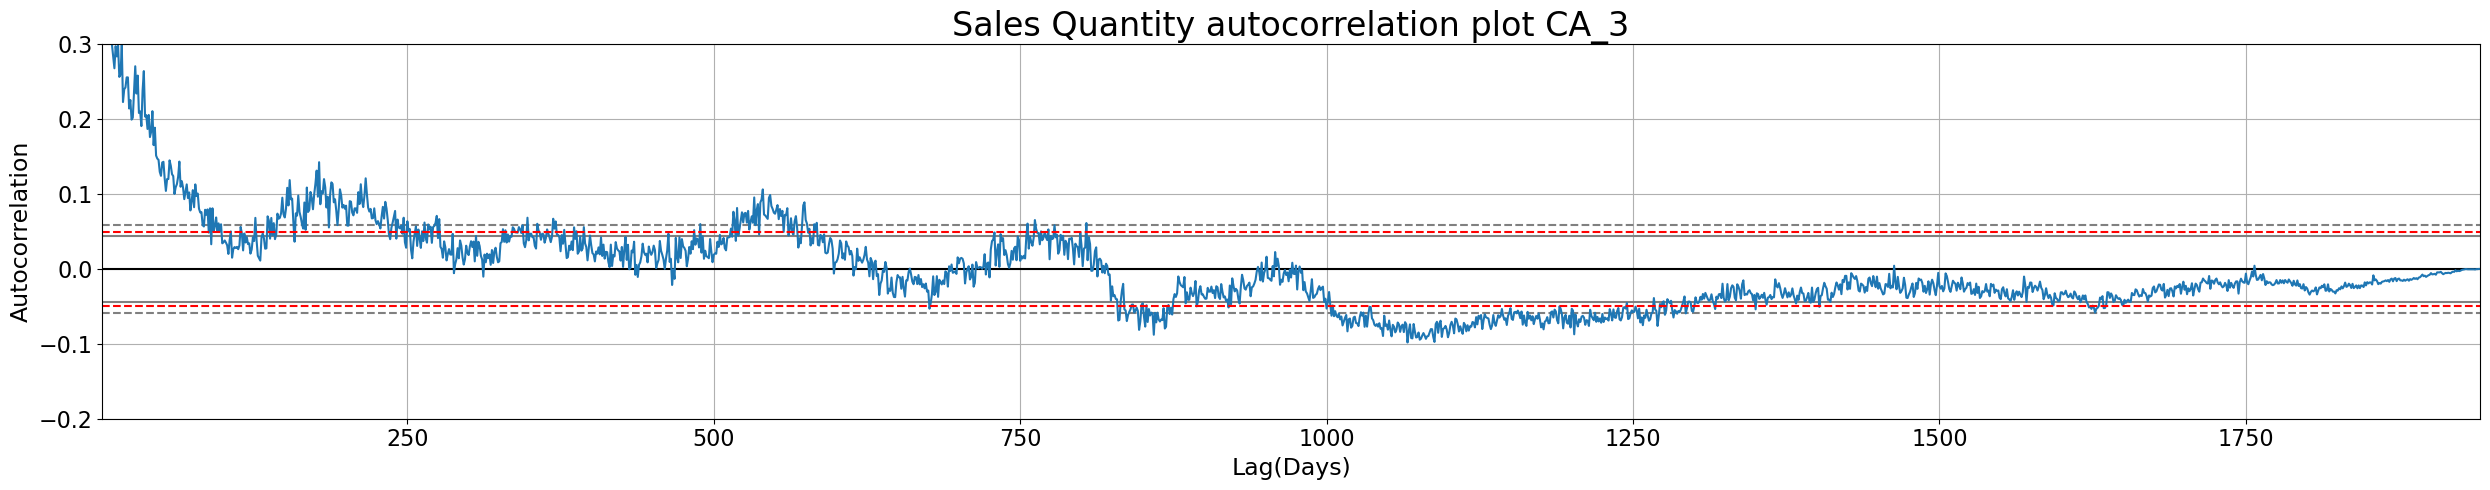

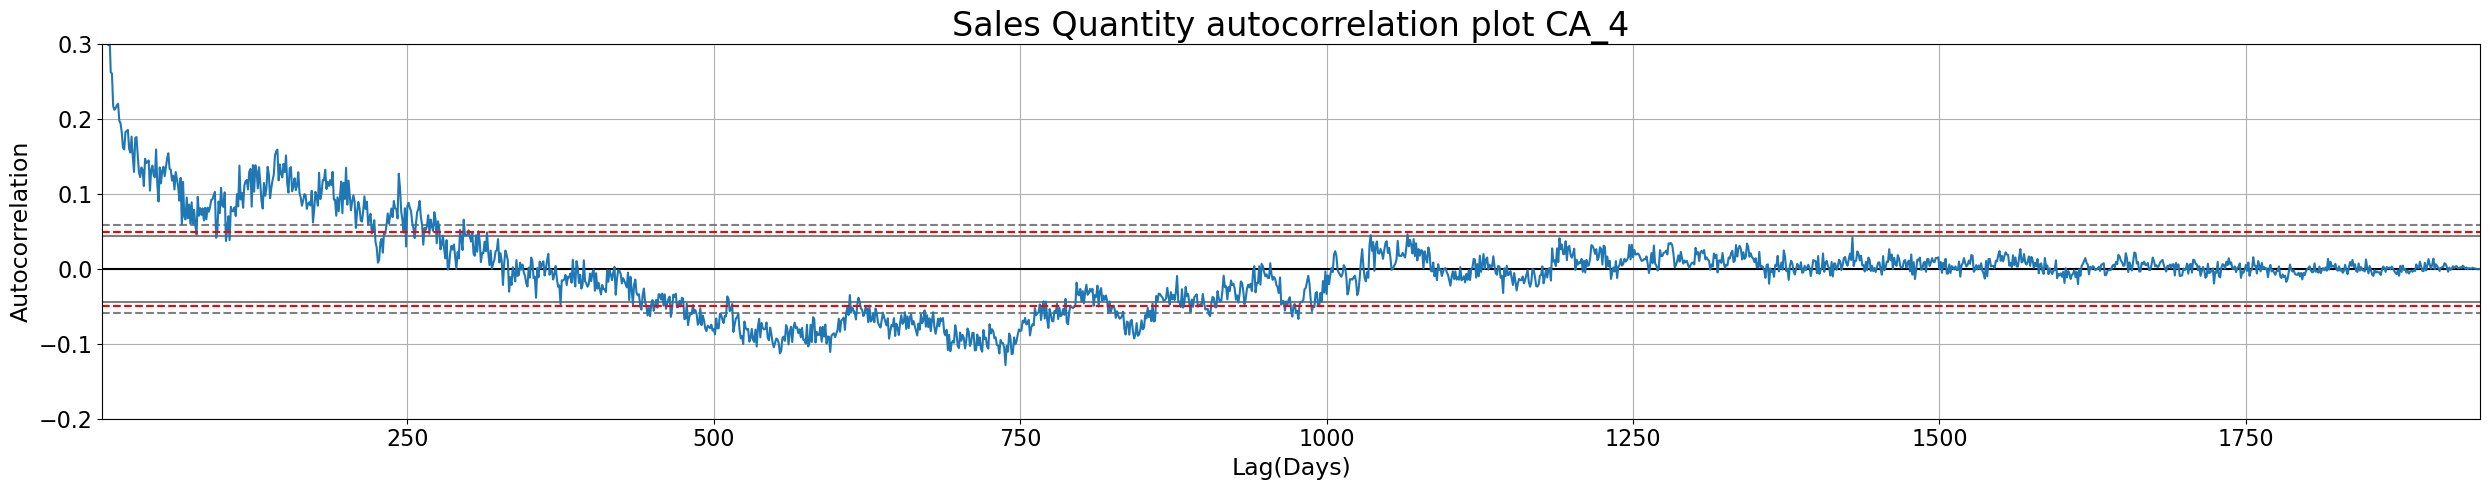

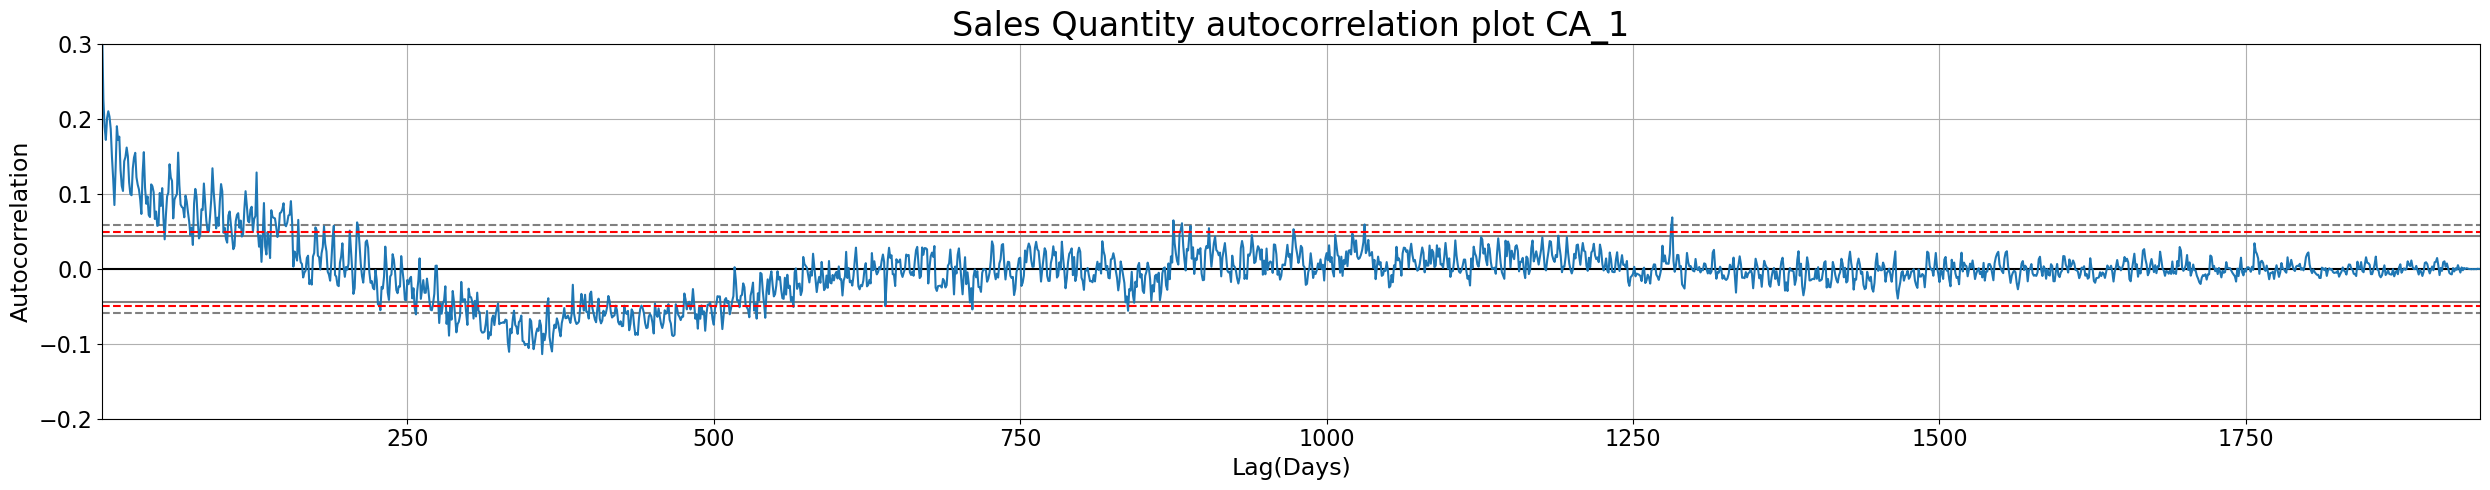

In [76]:
for store in full_data['store_id'].unique():

  mask=full_data['store_id']==store
  plt_data=full_data.loc[mask,:].sort_values(by='date')

  plt.figure(figsize=(25,5))
  autocorr_data=pd.plotting.autocorrelation_plot(plt_data['Sales_Quantity'])
  plt.axhline(y=0.05, color='red', linestyle='--')
  plt.axhline(y=-0.05, color='red', linestyle='--')
  plt.title(f"Sales Quantity autocorrelation plot {store}", fontsize=24)
  #plt.semilogy()
  plt.xlabel("Lag(Days)", fontsize=17)
  plt.ylabel("Autocorrelation", fontsize=17)
  plt.xticks(fontsize=16)
  plt.yticks(fontsize=16)
  plt.ylim(-0.2, 0.3)
  #plt.xlim(0, 250)

  
  
  plt.tight_layout()
  plt.show()


In [80]:
duckdb.query("""
DROP TABLE IF EXISTS my_table_autoco""")

In [81]:
duckdb.query("""

CREATE TEMPORARY TABLE my_table_autoco (
    Store VARCHAR(128),
    Mean_Cycle_Lag DOUBLE,
    Stdev_Cycle_Lag DOUBLE,
    Positive_Correlation_Lag DOUBLE
);""")


In [82]:



for store in full_data['store_id'].unique():

  mask=full_data['store_id']==store
  plt_data=full_data.loc[mask,:].sort_values(by='date')
    
  lags = np.arange(plt_data.shape[0])
  corr_coefs = np.zeros(plt_data.shape[0])

  for i in np.arange(len(lags)-2):
     x = plt_data['Sales_Quantity'].iloc[i:-1].reset_index(drop=True) # recent observations
     y = plt_data['Sales_Quantity'].iloc[:-i-1].reset_index(drop=True) # lag-shifted observations
      
     # the shapes must be the same
     if x.shape != y.shape:
        raise ValueError('shape mismatch!')
     # Pearson correlation multiplied by ... (to be answered in Quiz 1)
     corr_coefs[i] = x.corr(y,method='pearson')*x.shape[0]/plt_data['Sales_Quantity'].shape[0]

  print(f"store:{store}")
    
  cycle_lag = []
  lag = 0
  cycle = True
  direction_before = None
  direction_now = None
  flag=False
  lag2=0
  good_positive_corr_lags=[]
  good_negative_corr_lags=[]

  #for i, element in enumerate(corr_coefs):
  #    if element<=0.05:
  #        cut_off_index=i-1
  #       break

  for i in range(len(corr_coefs) - 1):
       curr = corr_coefs[i]
       next_ = corr_coefs[i + 1]
       
      
      # Determine direction
       if next_ > curr:
          direction_now = "rise"
       elif next_ < curr:
          direction_now = "fall"

      # Detect a change from falling to rising (start of a new cycle)
       if direction_before == "fall" and direction_now == "rise":
          cycle_lag.append(lag)
          lag = 0
          cycle = True

       lag += 1
       direction_before = direction_now


       lag2+=1
      
       if curr > 0.05 and -0.05 < next_ <= 0.05:
          good_positive_corr_lags.append(lag2)
          lag2 = 0

       if next_ > 0.05 and -0.05 < curr <= 0.05:
          lag2 = 0           
             
  r1=  np.mean(cycle_lag[1:])
  r2= np.std(cycle_lag[1:])
  r3= good_positive_corr_lags[0] if good_positive_corr_lags else None
      
  duckdb.query(f"""INSERT INTO my_table_autoco
                  VALUES ('{store}', {round(r1,2)}, {round(r2,2)}, {r3});""")       

  
  print("Cyle length mean ( the firstvalue not included)):", np.mean(cycle_lag[1:]),"stdev",np.std(cycle_lag[1:]))
  
  print("Lag with positive autocorrelation(left of graph):",good_positive_corr_lags[0])
  print(" This is the Days over which a sales quantity has a positive effect on future quantities")

result = duckdb.query("SELECT * FROM my_table_autoco").df()
result

store:TX_2
Cyle length mean ( the firstvalue not included)): 3.1396103896103895 stdev 1.3167215697935493
Lag with positive autocorrelation(left of graph): 109
 This is the Days over which a sales quantity has a positive effect on future quantities
store:WI_2
Cyle length mean ( the firstvalue not included)): 3.259696458684654 stdev 1.3457864701386955
Lag with positive autocorrelation(left of graph): 77
 This is the Days over which a sales quantity has a positive effect on future quantities


C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


store:TX_1
Cyle length mean ( the firstvalue not included)): 3.0093457943925235 stdev 1.187908923023226
Lag with positive autocorrelation(left of graph): 81
 This is the Days over which a sales quantity has a positive effect on future quantities


C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


store:TX_3
Cyle length mean ( the firstvalue not included)): 3.143089430894309 stdev 1.1443804942322948
Lag with positive autocorrelation(left of graph): 80
 This is the Days over which a sales quantity has a positive effect on future quantities
store:WI_3
Cyle length mean ( the firstvalue not included)): 3.257575757575758 stdev 1.3630470106902763
Lag with positive autocorrelation(left of graph): 46
 This is the Days over which a sales quantity has a positive effect on future quantities
store:CA_2
Cyle length mean ( the firstvalue not included)): 3.0731319554848966 stdev 1.2549652925911607
Lag with positive autocorrelation(left of graph): 115
 This is the Days over which a sales quantity has a positive effect on future quantities
store:WI_1
Cyle length mean ( the firstvalue not included)): 3.0234375 stdev 1.107254796148452
Lag with positive autocorrelation(left of graph): 138
 This is the Days over which a sales quantity has a positive effect on future quantities


...

store:CA_3
Cyle length mean ( the firstvalue not included)): 3.15625 stdev 1.2474686540202755
Lag with positive autocorrelation(left of graph): 90
 This is the Days over which a sales quantity has a positive effect on future quantities


C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


store:CA_4
Cyle length mean ( the firstvalue not included)): 3.0140625 stdev 1.179826150792459
Lag with positive autocorrelation(left of graph): 78
 This is the Days over which a sales quantity has a positive effect on future quantities
store:CA_1
Cyle length mean ( the firstvalue not included)): 3.7090558766859343 stdev 1.5905958199330192
Lag with positive autocorrelation(left of graph): 52
 This is the Days over which a sales quantity has a positive effect on future quantities


C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\CONDA\envs\data1030\Lib\site-packages\numpy\lib\_function_base_impl

,Store,Mean_Cycle_Lag,Stdev_Cycle_Lag,Positive_Correlation_Lag
0,TX_2,3.14,1.32,109.0
1,WI_2,3.26,1.35,77.0
2,TX_1,3.01,1.19,81.0
3,TX_3,3.14,1.14,80.0
4,WI_3,3.26,1.36,46.0
5,CA_2,3.07,1.25,115.0
6,WI_1,3.02,1.11,138.0
7,CA_3,3.16,1.25,90.0
8,CA_4,3.01,1.18,78.0
9,CA_1,3.71,1.59,52.0


In [85]:
from IPython.display import display
display(result[result.columns[1]].describe())
display(result[result.columns[2]].describe())
display(result[result.columns[3]].describe())

count    10.000000
mean      3.187000
std       0.209711
min       3.020000
25%       3.042500
50%       3.145000
75%       3.242500
max       3.720000
Name: Mean_Cycle_Lag, dtype: float64

count    10.000000
mean      1.276000
std       0.142611
min       1.110000
25%       1.182500
50%       1.255000
75%       1.342500
max       1.600000
Name: Stdev_Cycle_Lag, dtype: float64

count     10.000000
mean      86.600000
std       27.984917
min       46.000000
25%       77.250000
50%       80.500000
75%      104.250000
max      138.000000
Name: Positive_Correlation_Lag, dtype: float64

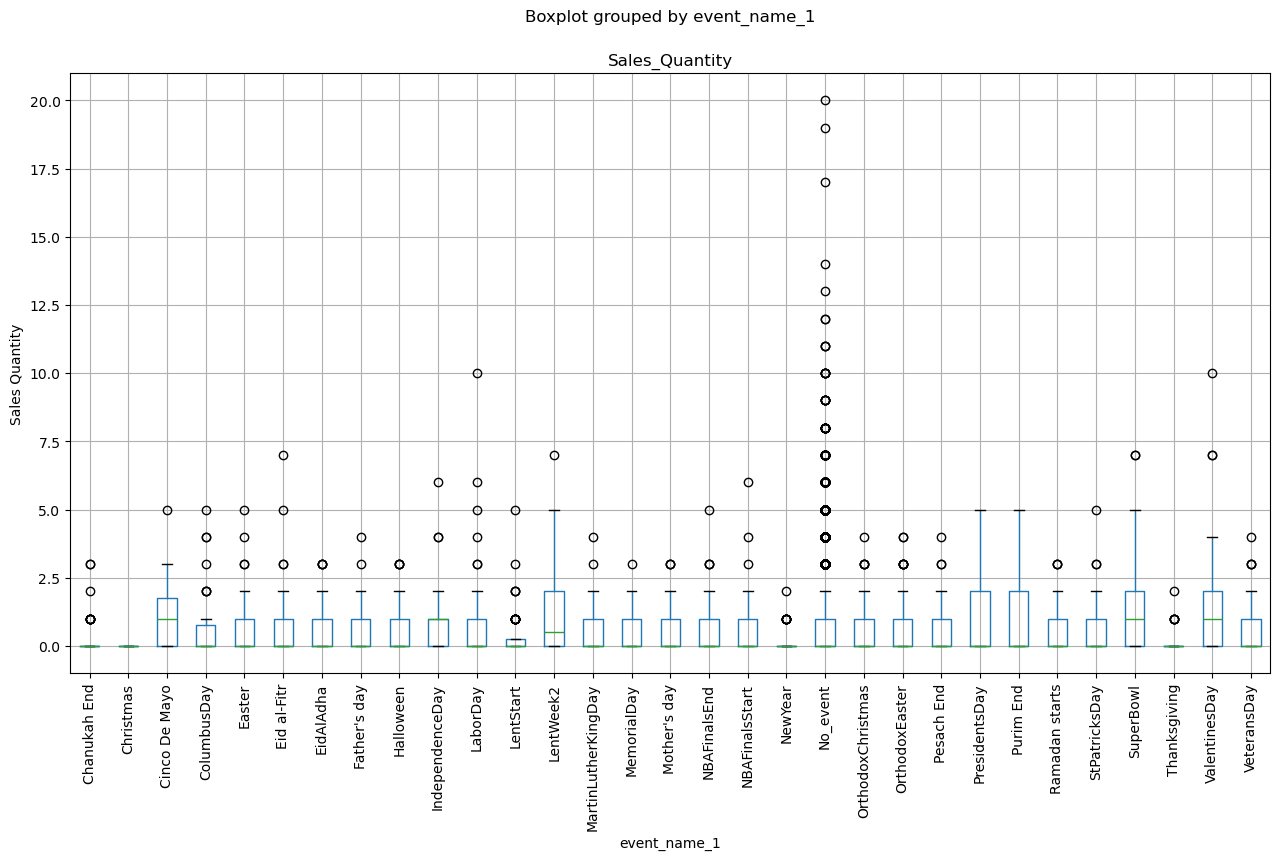

In [86]:
full_data[['Sales_Quantity','event_name_1']].boxplot(by='event_name_1',figsize=(15,8))
plt.ylabel('Sales Quantity')
plt.xlabel('event_name_1')
plt.xticks(rotation=90)
plt.show()

In [87]:
full_data = full_data.sort_values(by=['state_id','date']).reset_index(drop=True)

In [88]:
print(full_data.columns)

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'Day',
       'Sales_Quantity', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month',
       'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2',
       'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price'],
      dtype='object')


In [89]:
print(full_data['wday'].value_counts())

wday
1    2780
2    2780
3    2770
4    2770
5    2770
6    2770
7    2770
Name: count, dtype: int64


In [93]:
from sklearn.base import BaseEstimator, TransformerMixin

y = full_data['Sales_Quantity'] 
X = full_data.loc[:, full_data.columns != 'Sales_Quantity']

class CyclicalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, max_value):
        self.max_value = max_value

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.asarray(X)
        sin_x = np.sin(2 * np.pi * X / self.max_value)
        cos_x = np.cos(2 * np.pi * X / self.max_value)
        return np.c_[sin_x, cos_x]

        
onehot_ftrs=['event_name_1','event_type_1','event_name_2', 'event_type_2','snap_CA','snap_TX','snap_WI','store_id','state_id']
stand_ftrs=['sell_price']

preprocessor = ColumnTransformer(
    transformers=[
        ('month_enc', CyclicalEncoder(max_value=12), ['wday']),
        ('onehot', OneHotEncoder(sparse_output=False,handle_unknown='ignore'), onehot_ftrs),
        ('std', StandardScaler(), stand_ftrs)],
        
             )

prep = Pipeline(steps=[('preprocessor', preprocessor)])

train_rmse= []
test_rmse= []
coefs=[]


X_train, X_other, y_train, y_other= train_test_split(X,y, train_size=0.8,shuffle=False)
X_val, X_test, y_val, y_test= train_test_split(X_other,y_other, train_size=0.5, shuffle=False)

X_train_prep= prep.fit_transform(X_train)
X_val_prep= prep.transform(X_val)
X_test_prep=prep.transform(X_test)

# total data points
print(len(X_train_prep)+ len(X_val_prep)+ len(X_test_prep))
#No of Features
print(X_train_prep.shape)

19410
(15528, 66)


In [ ]:
help(Standard_scaler())

In [32]:
#find percentage

nothing="""

good_train_sizes=[]
remainder=0

for index, row in full_data.iterrows():
    
    if index==9500:
        print(index)
    train_df=full_data.iloc[0:index+1,:]
    
    remainder= int((full_data.shape[0]-(index+1))/2)
    
    val_df=full_data.iloc[index+1: index+remainder+1,:]
    test_df=full_data.iloc[index+remainder+1:,:]

    if index + remainder + 1 > full_data.shape[0]:
        break 

    def snap_distribution(df, col):
        
            grouped=df.groupby(col)[col].value_counts(normalize=True).reset_index(name='percentage')
            return grouped
        
        

    evtype1_train = snap_distribution(train_df, 'event_type_1')
    evtype1_val   = snap_distribution(val_df, 'event_type_1')
    evtype1_test  = snap_distribution(test_df, 'event_type_1')

    evname1_train = snap_distribution(train_df, 'event_name_1')
    evname1_val   = snap_distribution(val_df, 'event_name_1')
    evname1_test  = snap_distribution(test_df, 'event_name_1')

    evtype2_train = snap_distribution(train_df, 'event_type_2')
    evtype2_val   = snap_distribution(val_df, 'event_type_2')
    evtype2_test  = snap_distribution(test_df, 'event_type_2')

    evname2_train = snap_distribution(train_df, 'event_name_2')
    evname2_val   = snap_distribution(val_df, 'event_name_2')
    evname2_test  = snap_distribution(test_df, 'event_name_2')

    

    # test data leakage across train , val, test
    lists=[train_df['store_id'].unique(),val_df['store_id'].unique(),test_df['store_id'].unique()]
    
    sets = [set(lst) for lst in lists]

     
    all_unique = True
    #for i, s1 in enumerate(sets):
     #   for j, s2 in enumerate(sets):
     #       if i != j and s1.intersection(s2):
     #           #print(f"Overlap: fold {i} and {j}")
     #           all_unique = False
                
    #test imbalance in snapCA, snapTX, snapWI
    def similar_dist(d1, d2, tol=1.5):
        """Check if two distributions are within tolerance (in % difference)."""
        d1_renamed = d1.rename(columns={'percentage': 'percentage_1'})
        d2_renamed = d2.rename(columns={'percentage': 'percentage_2'})
        merged = pd.merge(d1, d2, on=d1.columns[0],suffixes=('_1', '_2'), how='outer').fillna(0)
        
        return (abs(merged['percentage_1'] - merged['percentage_2']) <= tol).all()

    if all_unique:
        if (
            similar_dist(evtype1_train, evtype1_val) and similar_dist(evtype1_train, evtype1_test)
            and similar_dist(evname1_train, evname1_val) and similar_dist(evname1_train, evname1_test)
            and similar_dist(evtype2_train, evtype2_val) and similar_dist(evtype2_train, evtype2_test)
            and similar_dist(evname2_train, evname2_val) and similar_dist(evname2_train, evname2_test)
        ):
            train_size = 100 * train_df.shape[0] / full_data.shape[0]
            good_train_sizes.append(train_size)
#    
#print("Good train size percentages:", good_train_sizes)   
"""


1
Good train size percentages: []
